<a href="https://colab.research.google.com/github/Karen-Kwatia/ai-course-lab0/blob/main/Exercise_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Task 1-Pandas Data Analysis
import pandas as pd
import numpy as np

In [6]:
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)
#Displaying information
df.describe()
df.info()

# Identify and count missing values
df.isnull().sum()


df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             200 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          200 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB


In [10]:
##Task 1-First TODO
#Displaying basic information about the dataset
print(df)

print(df.dtypes)#To display data types in the datasets
print(df.tail(10))#To display last 10 rows
print(df.head(10))#To display first 10 rows
print(df.columns)#To display columns in the dataset
print(df.describe)
##Second TODO
print(df.isnull().sum())#To count missing values

#Third TODO
major_means = df.groupby('major')['exam_score'].mean()
df['exam_score'] = df['exam_score'].fillna(df['major'].map(major_means))
#To verify that it is working
df['exam_score'].isnull().sum()

#Fourth TODO
year_medians = df.groupby('year')['hours_studied'].median()
df['hours_studied'] = df['hours_studied'].fillna(df['year'].map(year_medians))

df['hours_studied'].isnull().sum()

     student_id    major  year  exam_score  assignments_completed  \
0          1000  Physics     3   68.199753                     10   
1          1001  Biology     4   77.322537                      9   
2          1002       CS     3   77.930725                      9   
3          1003  Physics     1   67.856486                      2   
4          1004  Physics     4   93.657745                      6   
..          ...      ...   ...         ...                    ...   
195        1195     Math     4   60.925362                      2   
196        1196     Math     4   67.815558                     10   
197        1197  Biology     2   72.865528                      1   
198        1198       CS     4   78.109076                      9   
199        1199  Physics     1   89.753562                      2   

     hours_studied  
0        14.031175  
1        12.204873  
2         7.829556  
3        14.042336  
4        15.287370  
..             ...  
195      14.213931  
196

np.int64(0)

In [11]:
#Task 2
#First TODO -Calculate and display the average exam_score by major
#Calculating and displaying average score by each major
average_major = df.groupby('major')['exam_score'].mean()
print(average_major)

major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64


In [12]:
#Second TODO- Find the major with the highest average exam_score
best_major = average_major.idxmax()
print(best_major)

CS


In [13]:
#Third TODO-Calculate the correlation between hours_studied and exam_score
correlation = df['hours_studied'].corr(df['exam_score'])
print("Correlation between hours_studied and exam_score:", correlation)

Correlation between hours_studied and exam_score: -0.05598138347292439


In [18]:
#Fourth TODO-Create a new column 'performance' with categories:

def categorize_performance(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize_performance)
print("\nPerformance distribution:")
print(df['performance'].value_counts())




Performance distribution:
performance
Average              77
Needs Improvement    59
Good                 52
Excellent            12
Name: count, dtype: int64


In [15]:
#Task 3
#FIRST TODO-For each major and year combination, calculate:
#       - Number of students
#       - Average exam score
#       - Average hours studied

major_year_stats = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
)
print(major_year_stats)

              num_students  avg_exam_score  avg_hours_studied
major   year                                                 
Biology 1               13       76.570059          12.677806
        2               12       74.899613          13.426372
        3               14       80.178476          14.486815
        4               15       70.697689          14.253944
CS      1               12       77.098194          13.039480
        2                7       76.155936          13.995784
        3                9       72.347626          15.039892
        4               18       78.119997          16.275541
Math    1               11       74.053167          19.001215
        2                9       81.226714          12.345468
        3               10       72.017537          15.175871
        4               16       73.103066          17.419175
Physics 1               13       77.828686          13.489911
        2               12       73.277734          14.616778
        

In [16]:
#Second TODO-Identify top 5 students based on exam_score (handle ties appropriately)

top_students = df.nlargest(5, 'exam_score')
print(top_students)


     student_id    major  year  exam_score  assignments_completed  \
27         1027     Math     2  100.000000                      4   
57         1057       CS     2  100.000000                      8   
68         1068  Biology     3   98.146586                      1   
82         1082       CS     2   96.439441                      0   
132        1132       CS     4   96.330334                     10   

     hours_studied performance  
27        2.716265   Excellent  
57       11.870035   Excellent  
68       11.379991   Excellent  
82        7.378547   Excellent  
132      17.546891   Excellent  


In [17]:
#THIRD TODO -Create a pivot table showing average exam_score by major (rows) and year (columns)
pivot_table = df.pivot_table(index='major', columns='year', values='exam_score', aggfunc='mean')
print(pivot_table)



year             1          2          3          4
major                                              
Biology  76.570059  74.899613  80.178476  70.697689
CS       77.098194  76.155936  72.347626  78.119997
Math     74.053167  81.226714  72.017537  73.103066
Physics  77.828686  73.277734  73.134319  78.130194


EXERCISE 6


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

/tmp/ipykernel_931/2155641867.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot.boxplot(data_by_major, labels=majors)


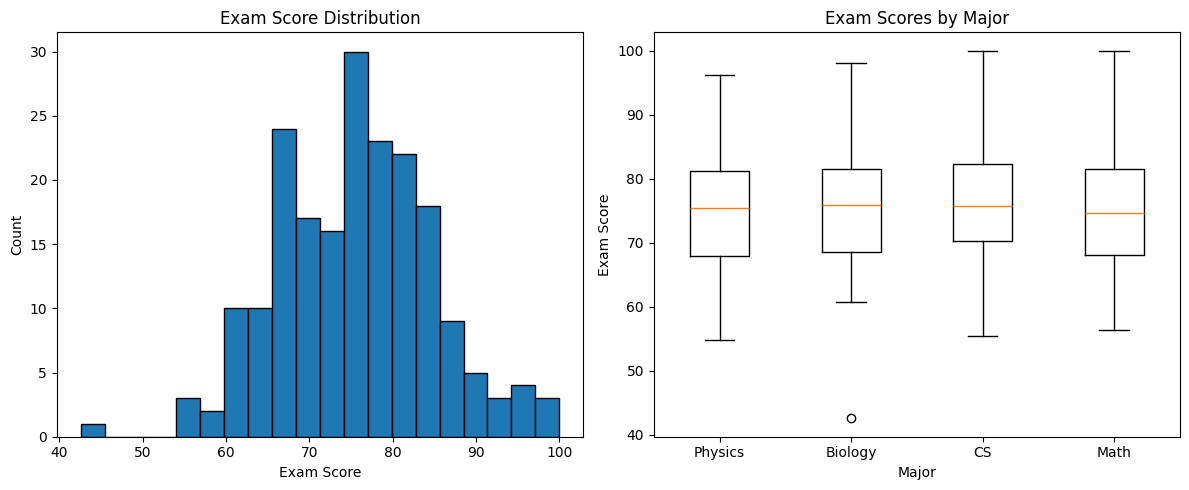

In [20]:
#Task 1-
#FIRST TODO-Create a figure with 2 subplots side by side
fig, (histogram, box_plot) = plt.subplots(1, 2, figsize=(12, 5))

histogram.hist(df['exam_score'].dropna(), bins=20, edgecolor='black')
histogram.set_title('Exam Score Distribution')
histogram.set_xlabel('Exam Score')
histogram.set_ylabel('Count')

majors = df['major'].unique()
data_by_major = [df[df['major'] == m]['exam_score'].dropna() for m in majors]
box_plot.boxplot(data_by_major, labels=majors)
box_plot.set_title('Exam Scores by Major')
box_plot.set_xlabel('Major')
box_plot.set_ylabel('Exam Score')

plt.tight_layout()
plt.show()


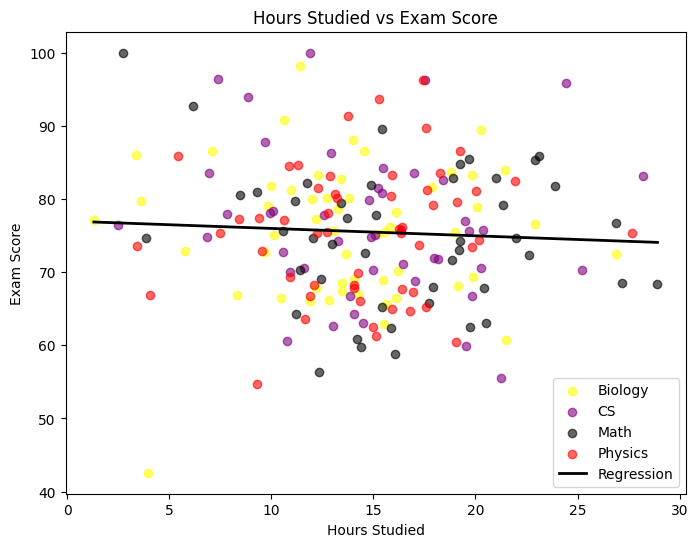

In [22]:
#Task 2-Relationship Visualization
fig, scatterplot = plt.subplots(figsize=(8, 6))

colors = {'CS': 'purple', 'Math': 'black', 'Physics': 'red', 'Biology': 'yellow'}
for major, group in df.groupby('major'):
    scatterplot.scatter(group['hours_studied'], group['exam_score'],
               label=major, color=colors[major], alpha=0.6)

clean = df[['hours_studied', 'exam_score']].dropna()
m, b = np.polyfit(clean['hours_studied'], clean['exam_score'], 1)
x = np.linspace(clean['hours_studied'].min(), clean['hours_studied'].max(), 100)
scatterplot.plot(x, m*x + b, color='black', linewidth=2, label='Regression')

scatterplot.set_title('Hours Studied vs Exam Score')
scatterplot.set_xlabel('Hours Studied')
scatterplot.set_ylabel('Exam Score')
scatterplot.legend()
plt.show()

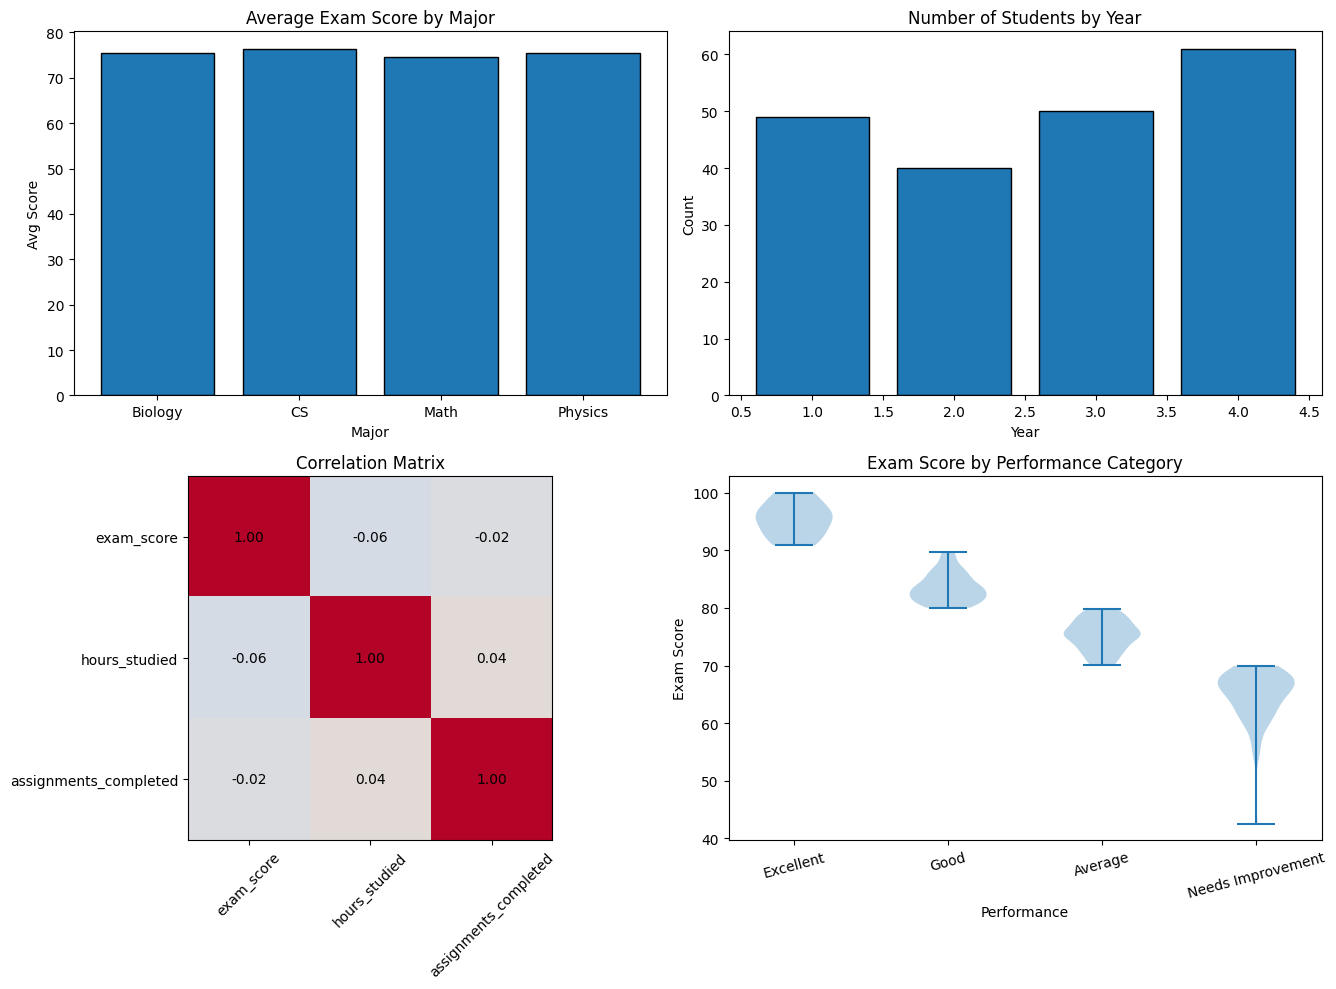

In [23]:
#Task 3
fig, ((bar_chart, count_plot), (heatmap, violin_plot)) = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart: Average exam score by major
avg_scores = df.groupby('major')['exam_score'].mean()
bar_chart.bar(avg_scores.index, avg_scores.values, edgecolor='black')
bar_chart.set_title('Average Exam Score by Major')
bar_chart.set_xlabel('Major')
bar_chart.set_ylabel('Avg Score')

# 2. Count plot: Number of students by year
year_counts = df['year'].value_counts().sort_index()
count_plot.bar(year_counts.index, year_counts.values, edgecolor='black')
count_plot.set_title('Number of Students by Year')
count_plot.set_xlabel('Year')
count_plot.set_ylabel('Count')

# 3. Heatmap: Correlation matrix
corr = df[['exam_score', 'hours_studied', 'assignments_completed']].corr()
heatmap.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
heatmap.set_xticks(range(len(corr.columns)))
heatmap.set_yticks(range(len(corr.columns)))
heatmap.set_xticklabels(corr.columns, rotation=45)
heatmap.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        heatmap.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
heatmap.set_title('Correlation Matrix')

# 4. Violin plot: Exam score by performance category
order = ['Excellent', 'Good', 'Average', 'Needs Improvement']
data_by_perf = [df[df['performance'] == p]['exam_score'].dropna() for p in order]
violin_plot.violinplot(data_by_perf)
violin_plot.set_xticks(range(1, len(order)+1))
violin_plot.set_xticklabels(order, rotation=15)
violin_plot.set_title('Exam Score by Performance Category')
violin_plot.set_xlabel('Performance')
violin_plot.set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

EXERCISE 7


In [ ]:
#Integration Challenge

In [24]:
np.random.seed(42)
n_customers = 500

In [25]:
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

In [26]:
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

In [27]:
# customer lifetime value (CLV) calculation
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])

In [28]:
#Creating age groups
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70'],
    include_lowest=True
)

In [29]:
#TODO: For each age group, calculate:
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV
group_stats = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
)
print(group_stats)

           num_customers    avg_income     avg_CLV      total_CLV
age_group                                                        
18-25                 81  50634.018330  718.371170   58188.064760
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70                186  50713.163384  762.693498  141860.990683


/tmp/ipykernel_931/3639449171.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = customers.groupby('age_group').agg(


In [30]:
#Identify top 10% of customers by CLV
clv_threshold = customers['CLV'].quantile(0.90)
top_customers = customers[customers['CLV'] >= clv_threshold]
print("Top 10% CLV threshold ",clv_threshold)
print("Number of top customers ",len(top_customers))

Top 10% CLV threshold  1222.9433034475207
Number of top customers  50


/tmp/ipykernel_931/940084926.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in customers.groupby('age_group'):


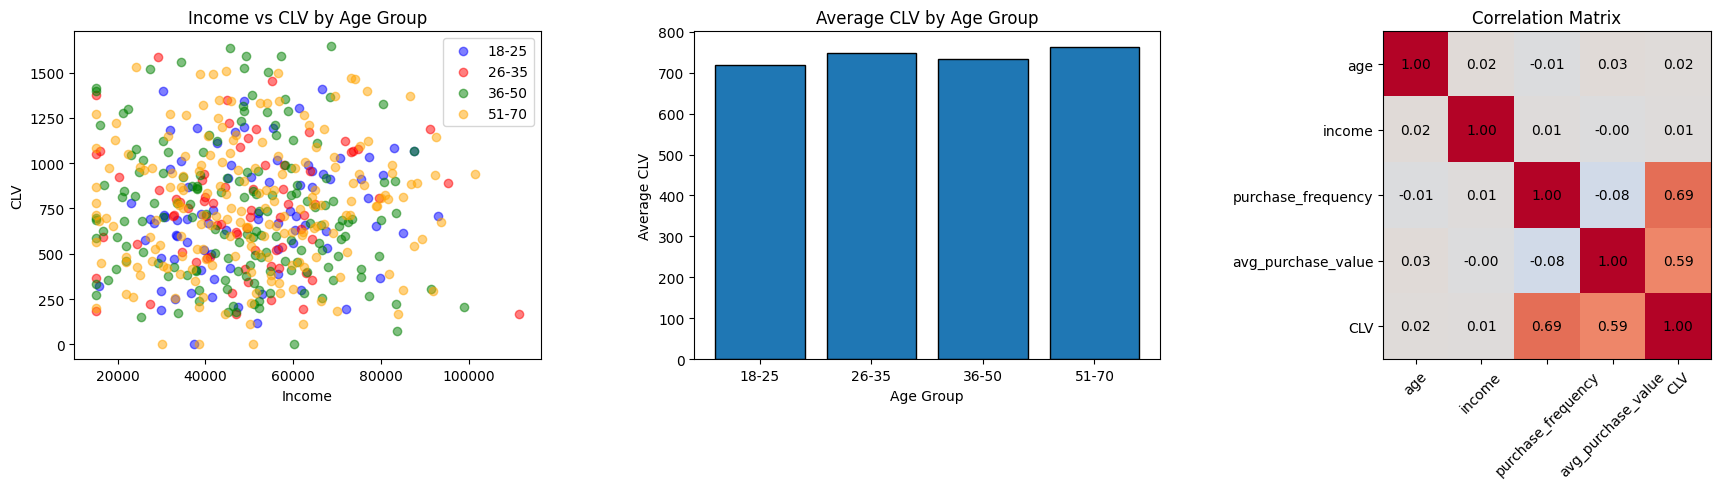

In [35]:
#Create Visualization
fig, (scatter, bar_chart, heatmap) = plt.subplots(1, 3, figsize=(18, 5))
#Scatter plot
colors = {'18-25': 'blue', '26-35': 'red', '36-50': 'green', '51-70': 'orange'}
for group, data in customers.groupby('age_group'):
    scatter.scatter(data['income'], data['CLV'],
                   label=group, color=colors[group], alpha=0.5)
scatter.set_title('Income vs CLV by Age Group')
scatter.set_xlabel('Income')
scatter.set_ylabel('CLV')
scatter.legend()

#Bar chart
bar_chart.bar(group_stats.index, group_stats['avg_CLV'], edgecolor='black')
bar_chart.set_title('Average CLV by Age Group')
bar_chart.set_xlabel('Age Group')
bar_chart.set_ylabel('Average CLV')

#Heatmap
corr = customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']].corr()
heatmap.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
heatmap.set_xticks(range(len(corr.columns)))
heatmap.set_yticks(range(len(corr.columns)))
heatmap.set_xticklabels(corr.columns, rotation=45)
heatmap.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        heatmap.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
heatmap.set_title('Correlation Matrix')

plt.tight_layout()
plt.show()

In [36]:
#KEY FINDINGS
#From this project I got to learn about CLV(Customer Lifetime Values) and it tells
#how important a customer is. The higher the clv the higher the value of the customer.
#I also got to learn about the libraies in python and their functions
#1. What age group has the clv
#2. Do older customers visit more than younger ones
#3.The CLV for the top 10%

#Recommendations:
#1. How do we motivate the lower customers to move up
#2. How do we offer loyalty points